✅ All imports successful!
(9564, 156)
      kepid kepoi_name   kepler_name         ra  ra_err        ra_str  \
0  10797460  K00752.01  Kepler-227 b  291.93423     0.0  19h27m44.22s   
1  10797460  K00752.02  Kepler-227 c  291.93423     0.0  19h27m44.22s   
2  10811496  K00753.01           NaN  297.00482     0.0  19h48m01.16s   

         dec  dec_err       dec_str  koi_gmag  ...  koi_insol_err1  \
0  48.141651      0.0  +48d08m29.9s    15.890  ...           29.45   
1  48.141651      0.0  +48d08m29.9s    15.890  ...            2.87   
2  48.134129      0.0  +48d08m02.9s    15.943  ...           31.04   

   koi_insol_err2  koi_srho  koi_srho_err1  koi_srho_err2  koi_fittype  \
0          -16.65   3.20796        0.33173       -1.09986      LS+MCMC   
1           -1.62   3.02368        2.20489       -2.49638      LS+MCMC   
2          -10.49   7.29555       35.03293       -2.75453      LS+MCMC   

   koi_score  mission  depth_x_duration  snr_ratio  
0      1.000   kepler         1821.228

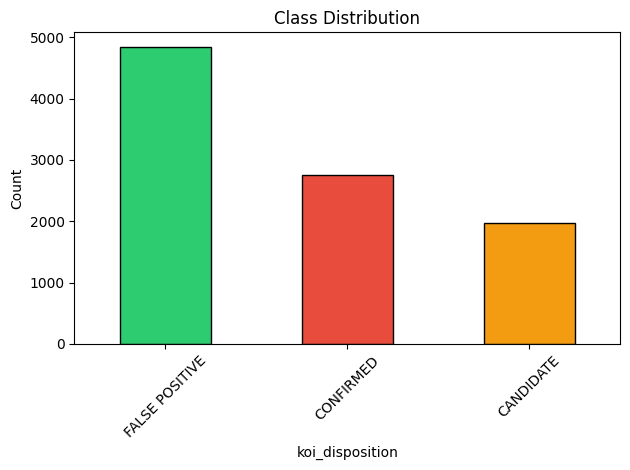

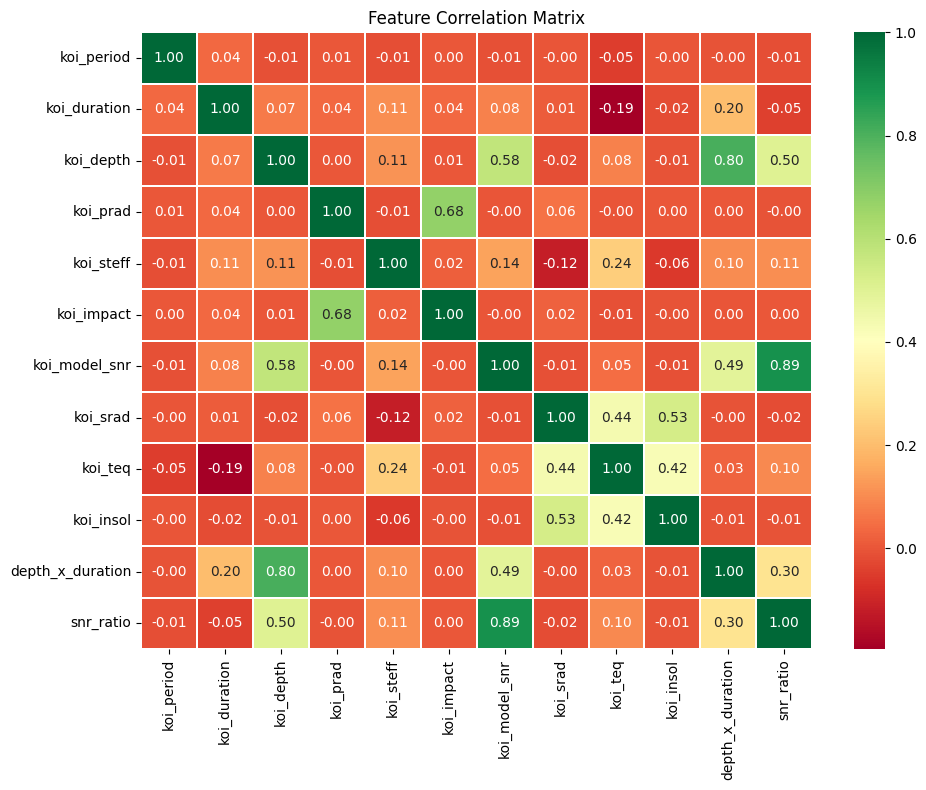

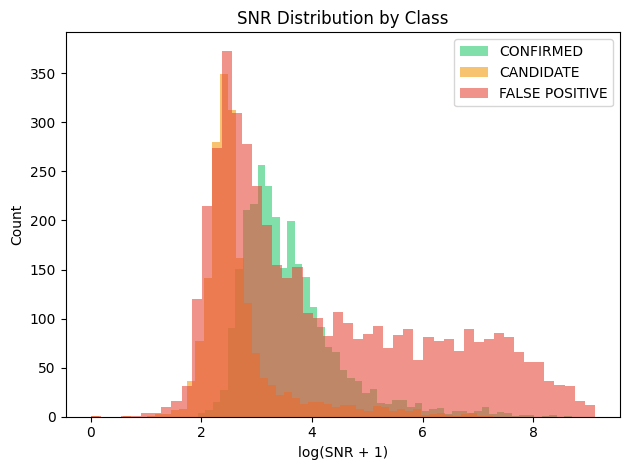

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All imports successful!")
df = pd.read_csv(r"c:\Users\prabh\exoplanet-hackathon\exoplanet-classifier\data\kepler_features.csv")
print(df.shape)
print(df.head(3))
print(df['koi_disposition'].value_counts())
FEATURES = ['koi_period','koi_duration','koi_depth','koi_prad',
            'koi_steff','koi_impact','koi_model_snr','koi_srad',
            'koi_teq','koi_insol','depth_x_duration','snr_ratio']

print(df[FEATURES].isnull().sum())
colors = ['#2ecc71','#e74c3c','#f39c12']
dist = df['koi_disposition'].value_counts()
dist.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
corr = df[FEATURES].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.3)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
colors = {'CONFIRMED':'#2ecc71', 'CANDIDATE':'#f39c12', 'FALSE POSITIVE':'#e74c3c'}
for label, color in colors.items():
    subset = df[df['koi_disposition']==label]['koi_model_snr'].dropna()
    plt.hist(np.log1p(subset), bins=50, alpha=0.6, label=label, color=color)

plt.title('SNR Distribution by Class')
plt.xlabel('log(SNR + 1)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()